## Fit Lx-T and T-Lx

In [ ]:
import sys
sys.path.append('/cosma/home/do012/dc-he4/anisotropy-flamingo/tools')
import warnings

import matplotlib.pyplot as plt
plt.style.use('../tools/academic-mplstyle/nice.mplstyle')
import numpy as np
import pandas as pd
from numba import set_num_threads
import emcee
import corner

import clusterfit as cf

# --------------------------------CONFIGURATION---------------------------------
InputFile = '../data/external/Lx-T-sample-Jay.txt'

Nthreads = 4

ScalingRelation = 'LX-T' #'LX-YSZ', 'LX-M', 'YSZ-M'] # give the name of the relation to fit if you want to fit only one. Set to False if you want to fit all relations.

BootstrapSteps = 400 # number of bootstrap steps to calculate uncertainties

ScatterStepSize = 0.006
BStepSize       = 0.003
logAStepSize    = 0.002

FIT_RANGE = {
        "logA_min": np.log10(0.1),
        "logA_max": np.log10(4.0),
        "B_min": 0.01,
        "B_max": 4.0,
        "scat_min": 0,
        "scat_max": 1,
    }
set_num_threads(Nthreads)

In [41]:
def log_likelihood(theta      : np.ndarray, 
                   logX_      : np.ndarray,
                   logY_      : np.ndarray,
                   sigma_obs_X: np.ndarray,
                   sigma_obs_Y: np.ndarray,
    ): 

    lp = log_prior(theta)
    if not np.isfinite(lp):
       return -np.inf 
    
    logA, B, sigma, = theta

    model = B * logX_ + logA
    sigma_tot2 = sigma_obs_Y**2 + B**2 * sigma_obs_X**2 + sigma**2
    lnL = -0.5 * np.sum((logY_ - model) ** 2 / (sigma_tot2) + np.log(sigma_tot2)) # Kostas' implementation

    return lnL + lp


# set prior
def log_prior(theta):
    # A large flat prior for now
    logA, B, sigma = theta # 6 parameters

    # If in range, p(theta)=1, else p(theta)=0
    if -2<logA<2 and 0.001<B<4 and 0.05<sigma<1:
        return 0.0
    else:
        return -np.inf

In [15]:
ClusterData = pd.read_csv(InputFile, delimiter='\t')
ClusterData

,Name,z,e_z,z_type,L500_05_2(1e42),L500_min,L500_max,T,T_min,T_max
0,J053038.5-222701,0.1733,0.0004,cg_spec_z,150.082,140.595,160.496,12.42,4.88,17.08
1,J124444.8-142552,0.3315,0.0081,photo_z,105.281,86.854,126.017,11.10,2.57,23.07
2,J102339.8+041108,0.2891,0.0004,cg_spec_z,982.080,922.633,1056.786,10.95,6.23,15.94
3,J113020.7-143425,0.1073,0.0004,cg_spec_z,161.947,153.883,170.936,9.93,5.29,20.33
4,J133340.1-231753,0.1260,0.0002,cg_spec_z,120.960,114.527,129.029,9.49,5.88,20.40
...,...,...,...,...,...,...,...,...,...,...
1386,J022940.1-121406,0.2760,0.0078,photo_z,38.252,29.265,49.506,0.51,0.35,0.92
1387,J070211.0-703727,0.0787,0.0002,cg_spec_z,2.398,1.602,3.611,0.49,0.32,0.90
1388,J035850.8-295249,0.1717,0.0042,photo_z,13.501,6.840,19.765,0.38,0.24,0.66
1389,J230557.8-442221,0.1318,0.0011,spec_z_boot,26.774,21.708,32.228,0.38,0.33,0.59


In [70]:
Y = ClusterData['L500_05_2(1e42)'].values
X = ClusterData['T'].values
z = ClusterData['z'].values
Ymax = ClusterData['L500_max'].values
Ymin = ClusterData['L500_min'].values
Xmax = ClusterData['T_max'].values
Xmin = ClusterData['T_min'].values

#The form is: log(Lx/Lpivot)=logA+Blog(T/Tpivot)+GAMMA*log(E(z)/E(z_pivot)), GAMMA=1.0
#For us: log(Lx/Lpivot) + gamma*log(E(z)/E(z_pivot))=logA+Blog(T/Tpivot), gamma=-1.0
gamma = 1.88
logY_ = cf._logY_(Y/10, z=z, CY=6.53, gamma=-gamma, Omega_m=0.28, Omega_L=0.72)
logY_ += gamma * np.log10(cf.E(z=0.25, Omega_m=0.28, Omega_L=0.72))

logX_ = cf._logX_(X, CX=2.27)

# Load error
scat_obs_Y = 0.5 * (Ymax - Ymin) / (Y * np.log(10))    #natural log?
scat_obs_X = 0.5 * (Xmax - Xmin) / (X * np.log(10))
# scat_obs_Y = np.log10(1 + eY) 
# scat_obs_X = np.log10(1 + eX)

In [71]:
# set the starting point for chain
pos0 = np.array([1, 1, 0.1]) + 1e-1 * np.random.rand(32, 3)
nwalkers, ndim = pos0.shape

# Sampler on multiple threads
sampler = emcee.EnsembleSampler(nwalkers, 
                                ndim, 
                                log_likelihood, 
                                args = (logX_, logY_, scat_obs_X, scat_obs_Y),
                                )

# Run
sampler.run_mcmc(pos0, 15000, progress=True)  # now the chain is saved. progress spam the standard output, toggled to False

# Convergence test
try:
    tau = sampler.get_autocorr_time()
    print(tau)
except emcee.autocorr.AutocorrError:
    print('The chain is too short to get a reliable autocorrelation time.')
    tau = 0

# Get the samples
flat_samples = sampler.get_chain(discard=1000, thin=80, flat=True)
print(flat_samples.shape)

100%|██████████| 15000/15000 [00:22<00:00, 669.45it/s]


[45.55105469 39.96560571 31.89489832]
(5600, 3)


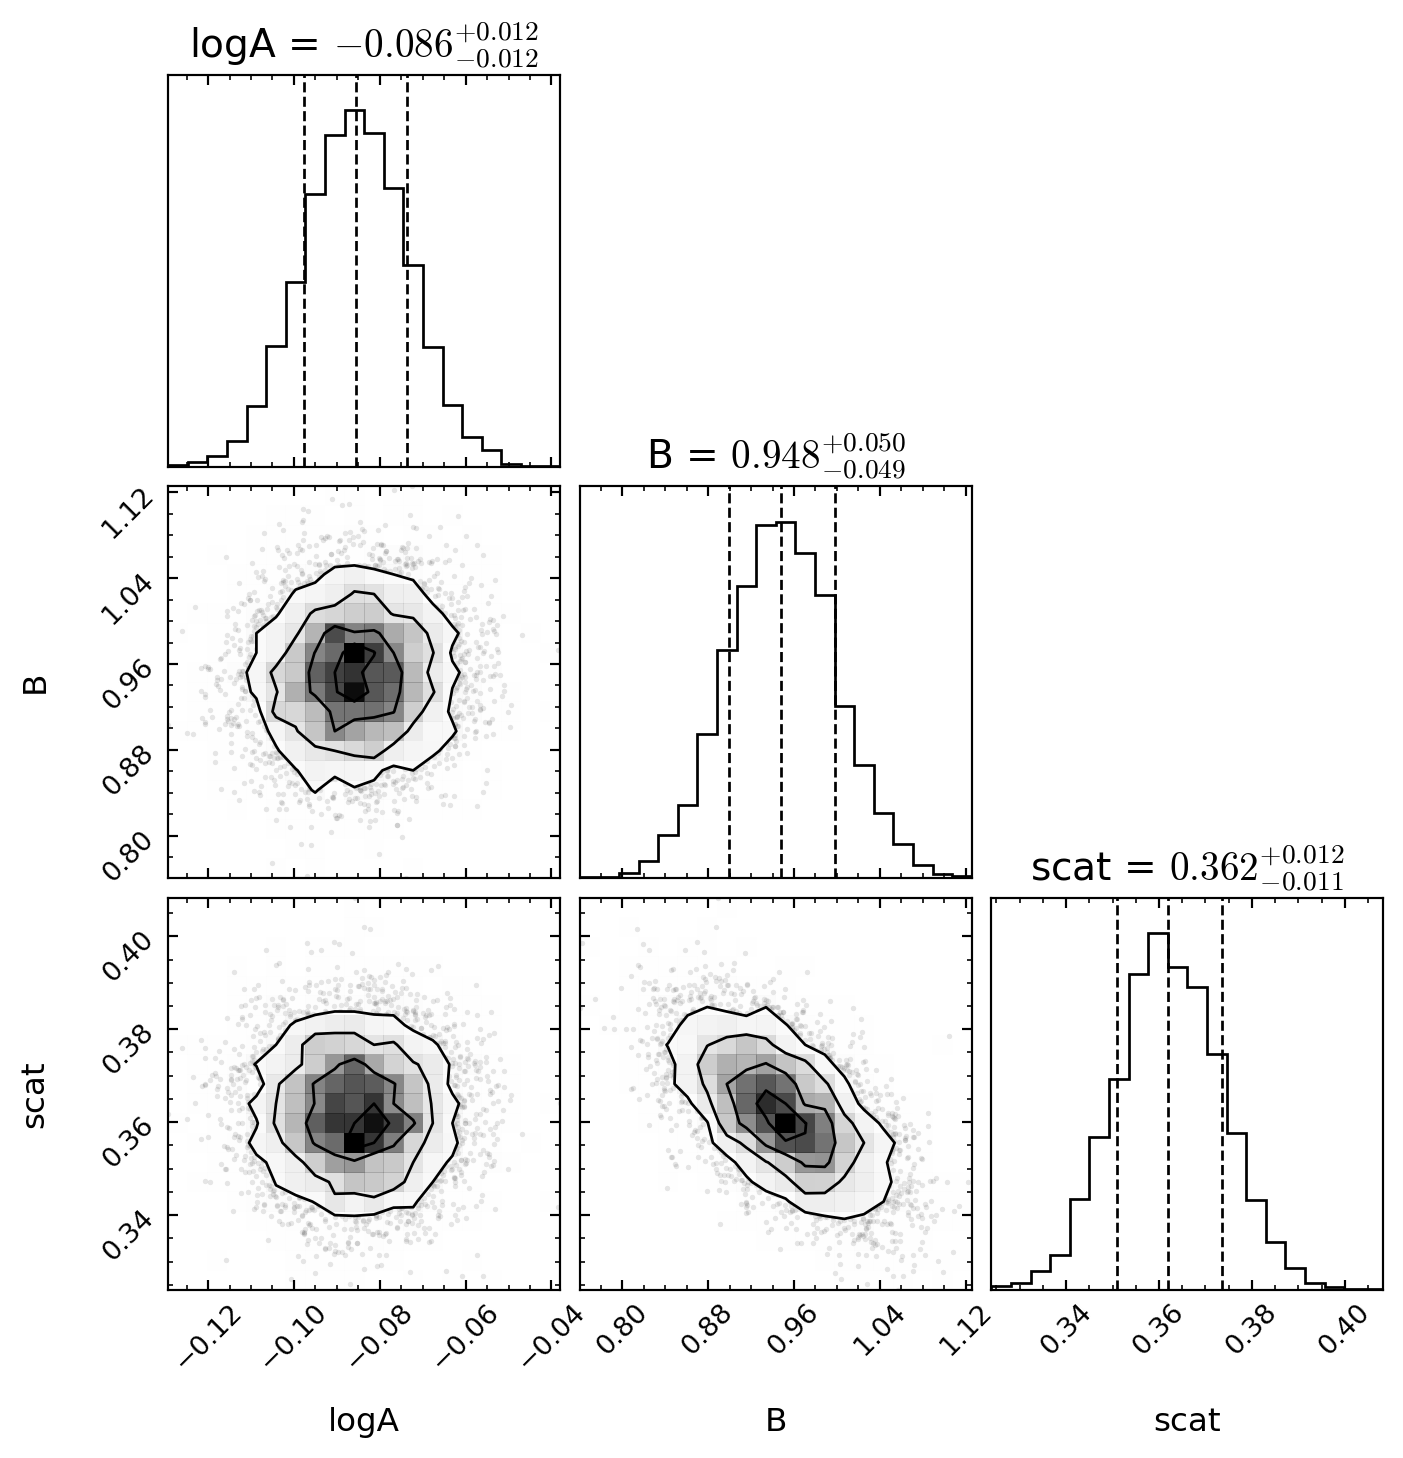

In [72]:
fig = corner.corner(
    flat_samples, labels=['logA', 'B', 'scat'], quantiles=[0.16, 0.5, 0.84], show_titles=True, title_fmt=".3f"
)

In [73]:
# T-Lx
# set the starting point for chain
pos0 = np.array([1, 1, 0.1]) + 1e-1 * np.random.rand(32, 3)
nwalkers, ndim = pos0.shape

# Sampler on multiple threads
sampler = emcee.EnsembleSampler(nwalkers, 
                                ndim, 
                                log_likelihood, 
                                args = (logY_, logX_, scat_obs_Y, scat_obs_X),
                                )

# Run
sampler.run_mcmc(pos0, 15000, progress=True)  # now the chain is saved. progress spam the standard output, toggled to False

# Convergence test
try:
    tau = sampler.get_autocorr_time()
    print(tau)
except emcee.autocorr.AutocorrError:
    print('The chain is too short to get a reliable autocorrelation time.')
    tau = 0

# Get the samples
flat_samples = sampler.get_chain(discard=1000, thin=80, flat=True)
print(flat_samples.shape)

100%|██████████| 15000/15000 [00:22<00:00, 672.60it/s]

[41.39439515 49.97762158 69.01045943]
(5600, 3)


In [74]:
flat_samples_plot = np.empty_like(flat_samples)
flat_samples_plot[:, 0] = - flat_samples[:, 0]
flat_samples_plot[:, 1] = 1 / flat_samples[:, 1]
# flat_samples_plot[:, 2] = flat_samples[:, 2]
flat_samples_plot[:, 2] = flat_samples[:, 2] * flat_samples_plot[:, 1] # project to y-axis

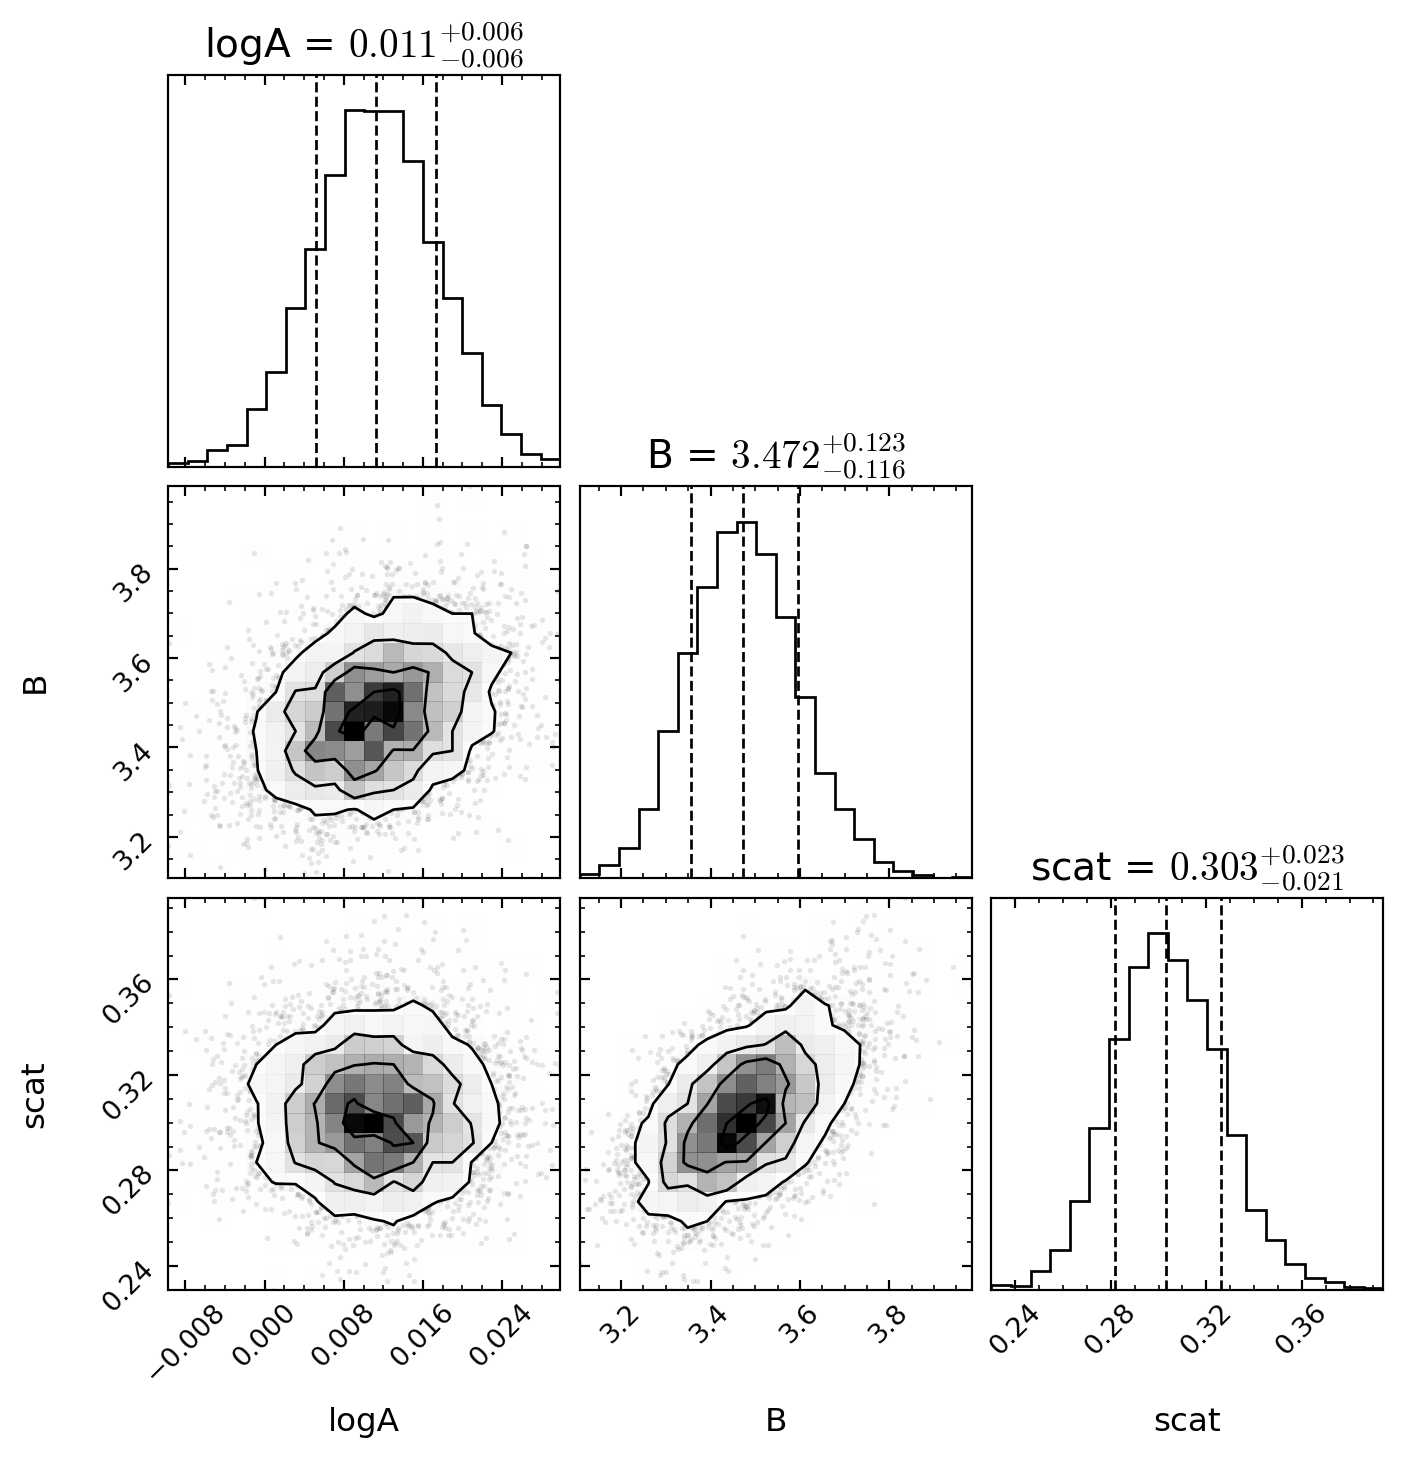

In [75]:
fig = corner.corner(
    flat_samples_plot, labels=['logA', 'B', 'scat'], quantiles=[0.16, 0.5, 0.84], show_titles=True, title_fmt=".3f"
)

In [18]:
# --------------------------------- Best fit --------------------------------- #

# Best fit
BestFitParams = cf.run_fit(
    logY_, logX_, **FIT_RANGE,
    scat_step  = ScatterStepSize,
    B_step     = BStepSize,
    logA_step  = logAStepSize,
    scat_obs_Y = scat_obs_Y,
    scat_obs_X = scat_obs_X,
    )
    
print('Best fit parameters:', BestFitParams)

Best fit parameters: {logA: 0.014000000000000012, B: 3.238, scat: 0.0, chi2: 0.9357575457335315}


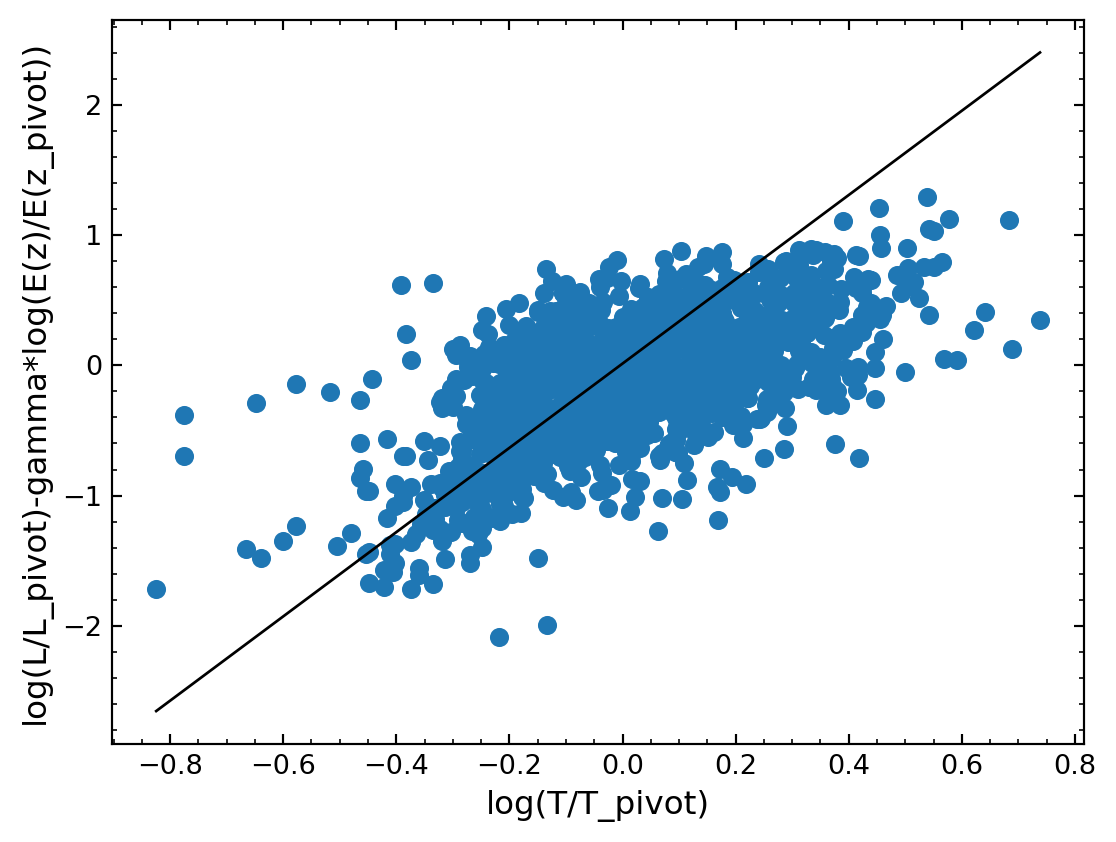

In [19]:
plt.scatter(logX_, logY_)
linlogX_ = np.linspace(np.min(logX_), np.max(logX_), num=100)
fitlogY_ = BestFitParams['logA'] + BestFitParams['B']*linlogX_
plt.plot(linlogX_, fitlogY_, color='k')
plt.ylabel('log(L/L_pivot)-gamma*log(E(z)/E(z_pivot))')
plt.xlabel('log(T/T_pivot)')
plt.show()

---
## Uncertainty

### The eX, eY errors?

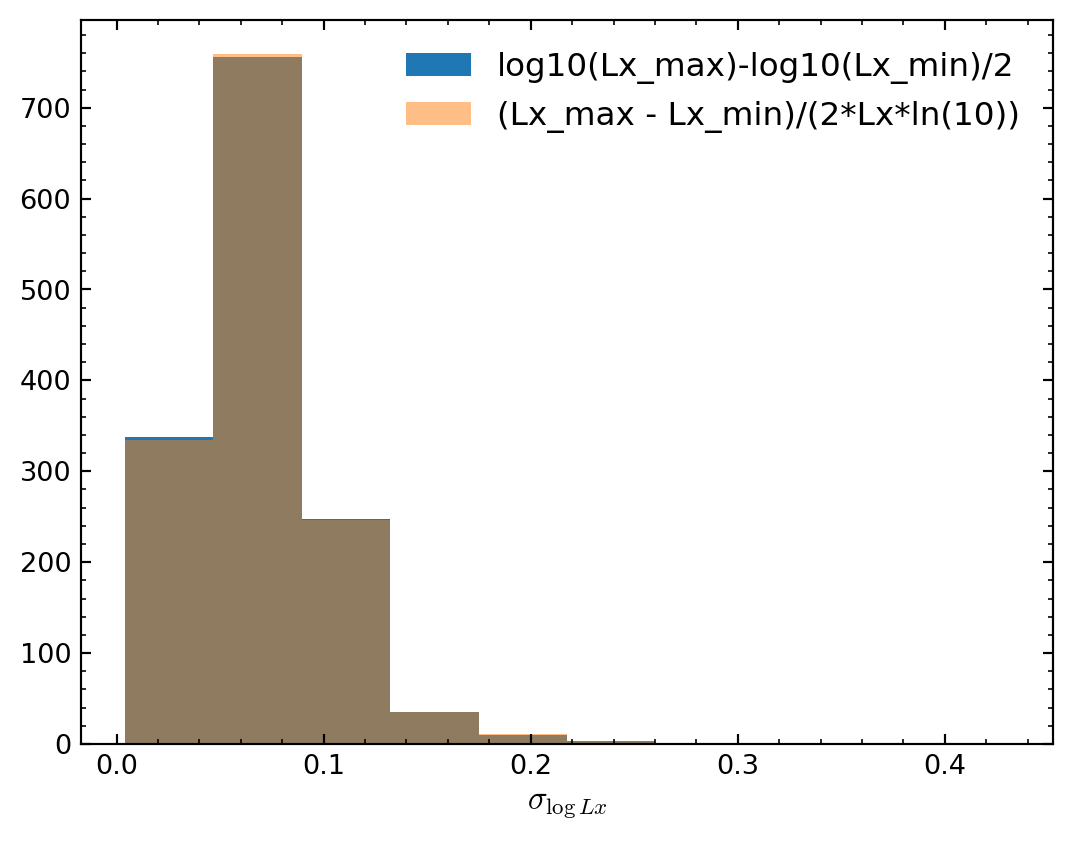

In [21]:
databins = plt.hist((np.log10(Ymax/Ymin))/2, label='log10(Lx_max)-log10(Lx_min)/2')
plt.hist(scat_obs_Y, alpha=0.5, bins=databins[1], label='(Lx_max - Lx_min)/(2*Lx*ln(10))')
plt.xlabel(r'$\sigma_{\log Lx}$')
plt.legend()
plt.show()

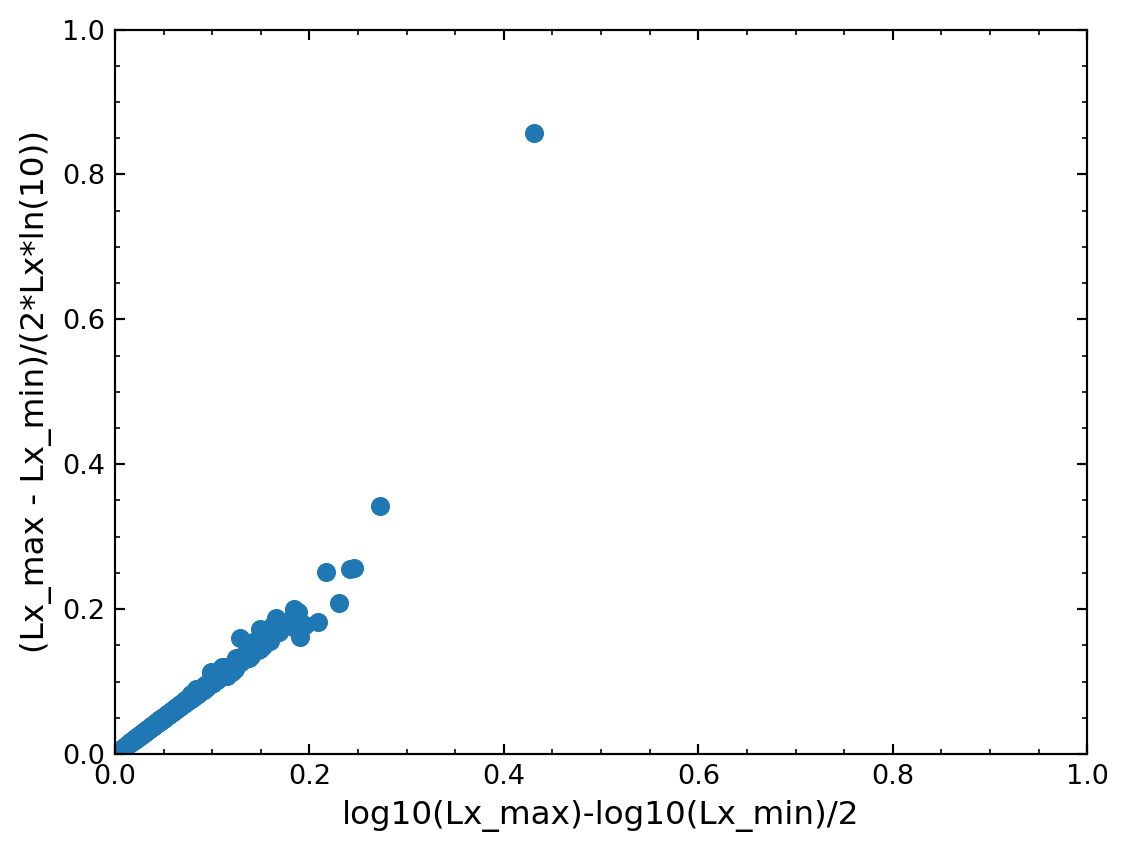

In [22]:
plt.scatter((np.log10(Ymax/Ymin))/2, scat_obs_Y)
plt.xlabel('log10(Lx_max)-log10(Lx_min)/2')
plt.ylabel('(Lx_max - Lx_min)/(2*Lx*ln(10))')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()